# Model Comparison and Final Model Selection

## Project: Machine Learning-Based U.S. Residential Rental Price Estimation System

This notebook compares the final models developed in the project and selects the model to be used for rental price estimation. The results are taken from the individual model notebooks:

| Model | Notebook |
|---|---|
| Ridge Regression | `03_Linear_Ridge_Models.ipynb` |
| Random Forest | `03_RandomForest_Thiwanka.ipynb` |
| Gradient Boosting | `04_GradientBoosting_Janeesha.ipynb` |
| Neural Network | `04_NeuralNetwork_Savindu.ipynb` |

All models were trained on `raw_train.csv` and evaluated on the same 35,920 listings of `raw_test.csv`, with the errors measured in dollars. Their test results are therefore directly comparable.

## 1. Test Set Results

For each model, the final (tuned) configuration is compared:

- **MAE:** average size of the error in dollars (lower is better).
- **RMSE:** like MAE, but large errors count more heavily (lower is better).
- **R²:** proportion of the variation in prices explained by the model (higher is better).

In [1]:
import matplotlib.pyplot as plt
import pandas as pd

# Test set results of the final configuration of each model,
# as reported in the individual notebooks
test_results = pd.DataFrame([
    {"Model": "Ridge Regression", "Configuration": "alpha = 10",
     "MAE": 242.01, "RMSE": 399.40, "R2": 0.6399},
    {"Model": "Random Forest", "Configuration": "Tuned_3",
     "MAE": 161.40, "RMSE": 301.84, "R2": 0.7943},
    {"Model": "Gradient Boosting", "Configuration": "Tuned_3",
     "MAE": 229.54, "RMSE": 381.75, "R2": 0.6710},
    {"Model": "Neural Network", "Configuration": "Tuned_5",
     "MAE": 149.48, "RMSE": 274.96, "R2": 0.8293}
]).set_index("Model").sort_values("MAE")

test_results["MAE rank"] = test_results["MAE"].rank().astype(int)

print("Test set results (35,920 listings):")
display(test_results)

Test set results (35,920 listings):


,Configuration,MAE,RMSE,R2,MAE rank
Model,,,,,
Neural Network,Tuned_5,149.48,274.96,0.8293,1
Random Forest,Tuned_3,161.40,301.84,0.7943,2
Gradient Boosting,Tuned_3,229.54,381.75,0.6710,3
Ridge Regression,alpha = 10,242.01,399.40,0.6399,4


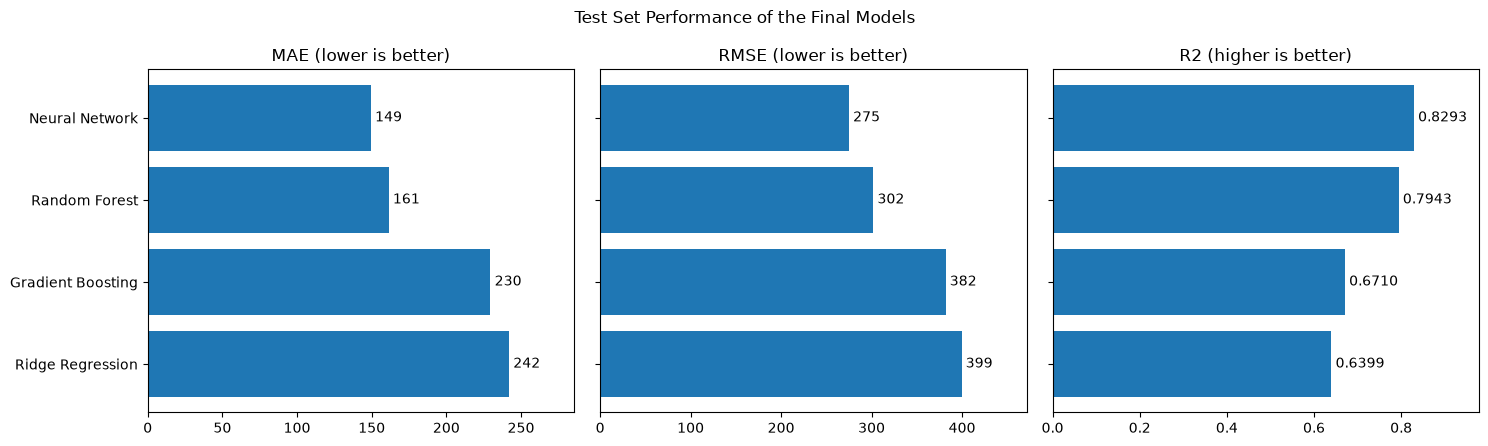

In [2]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

plot_order = test_results.index[::-1]

for axis, metric in zip(axes, ["MAE", "RMSE", "R2"]):
    values = test_results.loc[plot_order, metric]
    bars = axis.barh(plot_order, values)
    axis.bar_label(bars, fmt="%.4f" if metric == "R2" else "%.0f", padding=3)
    axis.set_title(f"{metric} ({'higher' if metric == 'R2' else 'lower'} is better)")
    axis.set_xlim(0, values.max() * 1.18)

axes[1].set_yticklabels([])
axes[2].set_yticklabels([])

plt.suptitle("Test Set Performance of the Final Models")
plt.tight_layout()
plt.show()

**Interpretation.**

- **The Neural Network is the most accurate model on all three metrics:** MAE \$149.48, RMSE \$274.96 and R² 0.8293.
- **The Random Forest is second.** Compared with it, the Neural Network reduces the MAE by \$11.92 (7.4%) and the RMSE by \$26.88 (8.9%). The larger reduction in RMSE shows that the Neural Network mainly makes fewer large errors.
- **Gradient Boosting and Ridge Regression are clearly weaker.** They explain 67% and 64% of the variation in prices, compared with about 80% for the two best models, and their MAE is about \$80 to \$90 higher.

## 2. Cross-Validation Results

The cross-validation results reported in the notebooks show whether the same ranking holds on the training data. The notebooks used different numbers of folds, so the values are compared by ranking. The Ridge Regression notebook used cross-validation only to select `alpha` and reports no cross-validation results in dollars.

In [3]:
cv_results = pd.DataFrame([
    {"Model": "Random Forest", "Folds": 3, "CV MAE": 172.01, "CV RMSE": 316.11, "CV R2": 0.7794},
    {"Model": "Gradient Boosting", "Folds": 5, "CV MAE": 231.69, "CV RMSE": 386.32, "CV R2": 0.6706},
    {"Model": "Neural Network", "Folds": 3, "CV MAE": 163.27, "CV RMSE": 293.00, "CV R2": 0.8105}
]).set_index("Model").sort_values("CV MAE")

print("Mean cross-validation results:")
display(cv_results)

Mean cross-validation results:


,Folds,CV MAE,CV RMSE,CV R2
Model,,,,
Neural Network,3,163.27,293.00,0.8105
Random Forest,3,172.01,316.11,0.7794
Gradient Boosting,5,231.69,386.32,0.6706


**Interpretation.** The ranking is the same as on the test set: Neural Network, then Random Forest, then Gradient Boosting. The Neural Network and the Random Forest were cross-validated on identical folds, and the Neural Network has the lower MAE (\$163.27 against \$172.01) and RMSE (\$293.00 against \$316.11). The ranking is therefore not the result of one particular test split.

## 3. Final Model Selection

| Criterion | Ridge Regression | Gradient Boosting | Random Forest | Neural Network |
|---|---|---|---|---|
| Test MAE | \$242.01 | \$229.54 | \$161.40 | **\$149.48** |
| Test RMSE | \$399.40 | \$381.75 | \$301.84 | **\$274.96** |
| Test R² | 0.6399 | 0.6710 | 0.7943 | **0.8293** |
| Cross-validation rank | – | 3 | 2 | **1** |
| Interpretability | High | Medium | Medium | Low |

### Selected model: Neural Network

The **Neural Network** (`04_NeuralNetwork_Savindu.ipynb`, configuration `Tuned_5`) is selected as the final model:

1. It has the best result on every test metric.
2. Cross-validation on the training data gives the same ranking, on the same folds as the Random Forest.
3. Its advantage comes from the periodic encoding of latitude and longitude, which allows it to represent local differences in rental prices.

**Limitations.** The Neural Network is the least interpretable model, and, like the other models, it is least accurate for very cheap and very expensive listings. Where a simple explanation of each prediction is more important than accuracy, the Random Forest is the best alternative: it is the second most accurate model and provides feature importances directly.